# Understanding Customer Feedback through NLP

**AUTHOR**  
Rodrigo Kang

## Overview

This notebook accompanies the portfolio project **Understanding Customer Feedback through NLP**. It implements a focused workflow for converting Amazon product reviews into evidence about customer sentiment and recurring concerns.

The analysis is deliberately compact. Each table or figure supports a modelling decision, tests model behaviour, or contributes directly to business interpretation. Broader theory belongs in the companion Quarto chapter.

The workflow has two parts:

1. a leakage-aware sentiment classifier evaluated on products not observed during training;
2. an exploratory topic model applied to English-language negative and neutral reviews.

The topic component is treated conservatively. Topic diagnostics support an analyst decision rather than being presented as an automatic or definitive model-selection procedure.

The notebook expects the project dependency specification in `requirements.txt`; exported outputs should be regenerated after any code change rather than carried forward from an earlier run.

## Imports and Configuration

The configuration below establishes deterministic seeds, validates the project layout and separates presentation outputs from diagnostic and processed artefacts. Warnings are filtered narrowly so that convergence or data-quality messages remain visible.

In [1]:
from __future__ import annotations

import html
import json
import random
import re
import warnings
from itertools import combinations
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from langdetect import DetectorFactory, LangDetectException, detect_langs
except ImportError as exc:
    raise ImportError(
        "This notebook requires the 'langdetect' package. "
        "Install the project dependencies before running the notebook."
    ) from exc

# Suppress known compatibility warnings while preserving model and data warnings.
warnings.filterwarnings("ignore", category=FutureWarning)

random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)
DetectorFactory.seed = random_seed

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.3f}".format)

plt.rcParams.update(
    {
        "figure.figsize": (9, 5.5),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)

notebook_name = "1-understanding-customer-feedback-nlp.ipynb"


def find_project_dir(start: Path) -> Path:
    """
    Locate the notebook directory from the current path or its parents.
    """
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / notebook_name).exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate {notebook_name} from {start}. "
        "Run the notebook from within the project repository."
    )


project_dir = find_project_dir(Path.cwd())
project_root = project_dir.parent

data_dir = project_root / "data"
raw_data_dir = data_dir / "raw"
processed_data_dir = data_dir / "processed"

output_dir = project_dir / "output"
figures_dir = output_dir / "figures"
tables_dir = output_dir / "tables"
diagnostics_dir = output_dir / "diagnostics"

review_category = "All_Beauty"
review_file = raw_data_dir / f"{review_category}.jsonl"
sample_file = processed_data_dir / "all-beauty-sample.jsonl"
sample_metadata_file = processed_data_dir / "all-beauty-sample-metadata.json"
prediction_file = processed_data_dir / "sentiment-test-predictions.csv.gz"

sample_size = 50_000
minimum_nlp_words = 3
minimum_language_characters = 20
minimum_english_probability = 0.80


def create_directories(directories: Iterable[Path]) -> None:
    """
    Create the required project directories.
    """
    for directory in directories:
        directory.mkdir(parents=True, exist_ok=True)


def save_figure(figure: plt.Figure, filename: str) -> Path:
    """
    Save a Matplotlib figure in the presentation output directory.
    """
    output_path = figures_dir / f"{filename}.png"
    figure.savefig(output_path, bbox_inches="tight")
    return output_path


def save_table(table: pd.DataFrame, filename: str) -> Path:
    """
    Export a presentation table as CSV.
    """
    output_path = tables_dir / f"{filename}.csv"
    table.to_csv(output_path, index=False)
    return output_path


def save_diagnostic(table: pd.DataFrame, filename: str) -> Path:
    """
    Export a diagnostic table as CSV.
    """
    output_path = diagnostics_dir / f"{filename}.csv"
    table.to_csv(output_path, index=False)
    return output_path


create_directories(
    [
        raw_data_dir,
        processed_data_dir,
        output_dir,
        figures_dir,
        tables_dir,
        diagnostics_dir,
    ]
)

## Data Loading

The complete `All_Beauty.jsonl` file is treated as a local research dataset. A deterministic reservoir sample of 50,000 reviews is created once and then reused. The metadata include the source filename, file size, modification timestamp, requested sample size and random seed, preventing silent reuse after either the configuration or source file changes.

In [2]:
def create_jsonl_sample(
    source_path: Path,
    destination_path: Path,
    metadata_path: Path,
    number_of_records: int,
    seed: int,
) -> dict[str, int]:
    """
    Create a reproducible reservoir sample from a JSONL dataset and
    save both the sampled records and their metadata.

    Inputs:
    -------
    source_path : Path
        Path to the source JSONL dataset.

    destination_path : Path
        Path where the sampled JSONL file will be saved.

    metadata_path : Path
        Path where the sample metadata will be stored.

    number_of_records : int
        Number of records to include in the sample.

    seed : int
        Random seed used for reproducible sampling.

    Outputs:
    --------
    dict[str, int]
        Dictionary containing metadata describing the generated sample.
    """
    if number_of_records <= 0:
        raise ValueError("number_of_records must be greater than zero.")

    if not source_path.exists():
        raise FileNotFoundError(f"Required source data were not found: {source_path}")

    generator = random.Random(seed)
    reservoir: list[dict] = []
    valid_records = 0
    invalid_records = 0

    with source_path.open("r", encoding="utf-8") as source:
        for line in source:
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                invalid_records += 1
                continue

            if valid_records < number_of_records:
                reservoir.append(record)
            else:
                replacement_index = generator.randint(0, valid_records)
                if replacement_index < number_of_records:
                    reservoir[replacement_index] = record

            valid_records += 1

    with destination_path.open("w", encoding="utf-8") as destination:
        for record in reservoir:
            destination.write(json.dumps(record, ensure_ascii=False) + "\n")

    source_stat = source_path.stat()
    metadata = {
        "source_filename": source_path.name,
        "source_size_bytes": source_stat.st_size,
        "source_modified_ns": source_stat.st_mtime_ns,
        "requested_sample_size": number_of_records,
        "random_seed": seed,
        "valid_records_scanned": valid_records,
        "invalid_records_skipped": invalid_records,
        "sample_records_saved": len(reservoir),
    }

    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    return metadata


def sample_is_current(
    metadata_path: Path,
    source_path: Path,
    size: int,
    seed: int,
) -> bool:
    """
    Verify whether an existing reusable sample matches the current
    dataset, sample size and random seed configuration.

    Inputs:
    -------
    metadata_path : Path
        Path to the sample metadata file.

    source_path : Path
        Path to the original JSONL dataset.

    size : int
        Expected sample size.

    seed : int
        Expected random seed.

    Outputs:
    --------
    bool
        True if the existing sample matches the current configuration;
        otherwise False.
    """
    if not metadata_path.exists():
        return False

    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

    configuration_matches = (
        metadata.get("source_filename") == source_path.name
        and metadata.get("requested_sample_size") == size
        and metadata.get("random_seed") == seed
        and metadata.get("source_size_bytes") is not None
        and metadata.get("source_modified_ns") is not None
    )

    if not configuration_matches:
        return False

    if not source_path.exists():
        return True

    source_stat = source_path.stat()

    return (
        metadata.get("source_size_bytes") == source_stat.st_size
        and metadata.get("source_modified_ns") == source_stat.st_mtime_ns
    )


if sample_file.exists() and sample_is_current(
    sample_metadata_file,
    review_file,
    sample_size,
    random_seed,
):
    sample_status = "existing validated sample"

elif review_file.exists():
    create_jsonl_sample(
        source_path=review_file,
        destination_path=sample_file,
        metadata_path=sample_metadata_file,
        number_of_records=sample_size,
        seed=random_seed,
    )
    sample_status = "new sample created"

else:
    raise FileNotFoundError(
        "Review data are required to run this notebook. "
        f"Place All_Beauty.jsonl at {review_file} or provide a "
        f"validated reusable sample at {sample_file}."
    )

reviews = pd.read_json(sample_file, lines=True)

if reviews.empty:
    raise ValueError(f"The review sample is empty: {sample_file}")

loading_summary = pd.DataFrame(
    {
        "metric": [
            "sample status",
            "loaded reviews",
            "loaded variables",
        ],
        "value": [
            sample_status,
            len(reviews),
            reviews.shape[1],
        ],
    }
)

display(loading_summary)

,metric,value
0,sample status,new sample created
1,loaded reviews,50000
2,loaded variables,10


## Initial Inspection and Data Preparation

The initial audit verifies the expected schema and quantifies missingness and whole-row duplication. The preparation stage then applies the analytical duplicate definition based on customer, product, review text and rating. Keeping both definitions explicit avoids an apparent discrepancy between audit and cleaning counts.

In [3]:
def normalise_nested_value(value):
    """
    Convert nested Python objects into a hashable string representation.

    Inputs:
    -------
    value : Any
        Value to normalise.

    Outputs:
    --------
    Any
        JSON string for lists and dictionaries; otherwise the original value.
    """
    if isinstance(value, (list, dict)):
        return json.dumps(value, sort_keys=True, ensure_ascii=False)

    return value


def make_dataframe_hashable(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Convert all nested object columns into hashable representations to
    enable duplicate detection and uniqueness calculations.

    Inputs:
    -------
    dataframe : pandas.DataFrame
        Input DataFrame that may contain nested Python objects.

    Outputs:
    --------
    pandas.DataFrame
        Copy of the original DataFrame with hashable object columns.
    """
    hashable = dataframe.copy()

    for column in hashable.select_dtypes(include="object").columns:
        hashable[column] = hashable[column].map(normalise_nested_value)

    return hashable


required_columns = ["rating", "text", "parent_asin"]

missing_columns = [
    column for column in required_columns
    if column not in reviews.columns
]

if missing_columns:
    raise ValueError(
        "Required review columns are missing: "
        + ", ".join(missing_columns)
    )

hashable_reviews = make_dataframe_hashable(reviews)

whole_row_duplicates = int(hashable_reviews.duplicated().sum())

schema_table = pd.DataFrame(
    {
        "column": reviews.columns,
        "data_type": reviews.dtypes.astype(str).values,
        "missing_values": reviews.isna().sum().values,
        "missing_share": reviews.isna().mean().values,
        "unique_values": [
            hashable_reviews[column].nunique(dropna=True)
            for column in reviews.columns
        ],
    }
)

save_diagnostic(schema_table, "review-schema")

display(
    pd.DataFrame(
        {
            "metric": [
                "rows",
                "columns",
                "whole-row duplicates",
                "memory (MB)",
            ],
            "value": [
                len(reviews),
                reviews.shape[1],
                whole_row_duplicates,
                reviews.memory_usage(deep=True).sum() / 1_000_000,
            ],
        }
    )
)

display(schema_table)

,metric,value
0,rows,50000.000
1,columns,10.000
2,whole-row duplicates,45.000
3,memory (MB),33.326


,column,data_type,missing_values,missing_share,unique_values
0,rating,int64,0,0.000,5
1,title,object,0,0.000,33030
2,text,object,0,0.000,47695
3,images,object,0,0.000,4254
4,asin,object,0,0.000,26171
5,parent_asin,object,0,0.000,25491
6,user_id,object,0,0.000,49334
7,timestamp,datetime64[ns],0,0.000,49952
8,helpful_vote,int64,0,0.000,90
9,verified_purchase,bool,0,0.000,2


In [4]:
def prepare_review_data(review_data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Clean and prepare the raw review dataset for analysis while
    generating a compact audit trail of all preprocessing steps.

    Inputs:
    -------
    review_data : pandas.DataFrame
        Raw review dataset.

    Outputs:
    --------
    tuple[pandas.DataFrame, pandas.DataFrame]
        First element:
            Cleaned review dataset ready for analysis.

        Second element:
            Audit table summarising the preprocessing pipeline.
    """
    preferred_columns = [
        "rating",
        "title",
        "text",
        "images",
        "helpful_vote",
        "verified_purchase",
        "timestamp",
        "parent_asin",
        "user_id",
    ]

    data = review_data[
        [column for column in preferred_columns if column in review_data]
    ].copy()

    input_rows = len(data)

    for column in ["title", "text", "parent_asin"]:
        if column not in data:
            data[column] = ""

        data[column] = (
            data[column]
            .fillna("")
            .astype(str)
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )

    data["rating"] = pd.to_numeric(data["rating"], errors="coerce")

    invalid_rating = ~data["rating"].between(1, 5)
    empty_text = data["text"].eq("")
    missing_product = data["parent_asin"].eq("")

    data = data.loc[
        ~(invalid_rating | empty_text | missing_product)
    ].copy()

    duplicate_subset = [
        column
        for column in ["user_id", "parent_asin", "text", "rating"]
        if column in data
    ]

    analytical_duplicates = data.duplicated(
        subset=duplicate_subset,
        keep="first",
    )

    analytical_duplicate_count = int(analytical_duplicates.sum())

    data = data.loc[~analytical_duplicates].copy()

    data["helpful_vote"] = (
        pd.to_numeric(
            data.get("helpful_vote", 0),
            errors="coerce",
        )
        .fillna(0)
        .clip(lower=0)
        .astype("int64")
    )

    verified = data.get("verified_purchase", False)

    if not pd.api.types.is_bool_dtype(verified):
        verified = (
            verified.astype(str)
            .str.lower()
            .map(
                {
                    "true": True,
                    "false": False,
                }
            )
        )

    data["verified_purchase"] = (
        verified
        .fillna(False)
        .astype(bool)
    )

    # Dates are not used downstream, so retain the source timestamp without
    # converting it. This avoids reinterpreting already-parsed datetimes as
    # millisecond integers and keeps preparation focused on analytical fields.

    data["word_count"] = data["text"].str.split().str.len()

    data = data.reset_index(drop=True)

    audit = pd.DataFrame(
        {
            "metric": [
                "input rows",
                "whole-row duplicates in raw sample",
                "invalid ratings",
                "empty review text",
                "missing product identifiers",
                "analytical duplicates removed",
                "prepared rows",
                "retention rate",
            ],
            "value": [
                input_rows,
                whole_row_duplicates,
                int(invalid_rating.sum()),
                int(empty_text.sum()),
                int(missing_product.sum()),
                analytical_duplicate_count,
                len(data),
                len(data) / input_rows,
            ],
        }
    )

    return data, audit


prepared_reviews, data_audit = prepare_review_data(reviews)

save_table(data_audit, "data-audit")

data_audit_display = data_audit.copy()
data_audit_display["display_value"] = [
    f"{value:.1%}" if metric == "retention rate" else f"{int(value):,}"
    for metric, value in zip(
        data_audit_display["metric"],
        data_audit_display["value"],
    )
]
display(data_audit_display[["metric", "display_value"]])

,metric,display_value
0,input rows,"50,000"
1,whole-row duplicates in raw sample,45
2,invalid ratings,0
3,empty review text,47
4,missing product identifiers,0
5,analytical duplicates removed,46
6,prepared rows,"49,907"
7,retention rate,99.8%


## Exploratory Analysis

The exploratory analysis is limited to the class imbalance that directly affects the modelling design. Review-length medians remain in the summary table because they help interpret text coverage, but a separate distribution figure would not alter a modelling or business decision.

In [5]:
rating_summary = (
    prepared_reviews.groupby("rating", observed=True)
    .agg(reviews=("text", "size"), median_words=("word_count", "median"))
    .reset_index()
)
rating_summary["review_share"] = rating_summary["reviews"] / rating_summary["reviews"].sum()
rating_summary["rating"] = rating_summary["rating"].astype("int64")
rating_summary["median_words"] = rating_summary["median_words"].astype("int64")

save_table(rating_summary, "rating-summary")

obsolete_rating_figure = figures_dir / "rating-distribution.png"
obsolete_rating_figure.unlink(missing_ok=True)

display(
    rating_summary.style.format(
        {
            "reviews": "{:,.0f}",
            "median_words": "{:,.0f}",
            "review_share": "{:.1%}",
        }
    )
)

,rating,reviews,median_words,review_share
0,1,"7,304",20,14.6%
1,2,"3,017",24,6.0%
2,3,"4,019",24,8.1%
3,4,"5,635",25,11.3%
4,5,"29,932",17,60.0%


## Text Preparation and Language Scope

Only review bodies enter the models. Rating-derived titles remain available for audit but are excluded from features because they can directly reveal the rating-based target.

The modelling corpus is restricted to reviews detected as English with at least 0.80 probability. This keeps the use of English stop words and the interpretation of English topics methodologically consistent. Short or uncertain texts remain in the data audit but are excluded from modelling.

Because language detection and minimum-length rules remove many very short reviews, retention is reported by rating. The resulting models describe usable English-language reviews rather than the complete review population; short positive reviews are disproportionately likely to be excluded.

In [6]:
url_pattern = re.compile(r"(?:https?://|www\.)\S+", flags=re.IGNORECASE)
html_tag_pattern = re.compile(r"<[^>]+>")
platform_token_pattern = re.compile(r"\[\[(?:VIDEOID|IMAGEID):[^\]]+\]\]", flags=re.IGNORECASE)
non_word_pattern = re.compile(r"[^a-z0-9']+")
space_pattern = re.compile(r"\s+")
rating_title_pattern = re.compile(
    r"^(?:one|two|three|four|five|1|2|3|4|5)\s+stars?$",
    flags=re.IGNORECASE,
)

contractions = {
    r"\bcan't\b": "can not",
    r"\bwon't\b": "will not",
    r"\bdidn't\b": "did not",
    r"\bdoesn't\b": "does not",
    r"\bdon't\b": "do not",
    r"\bisn't\b": "is not",
    r"\baren't\b": "are not",
    r"\bwasn't\b": "was not",
    r"\bweren't\b": "were not",
    r"\bhasn't\b": "has not",
    r"\bhaven't\b": "have not",
    r"\bhadn't\b": "had not",
    r"\bwouldn't\b": "would not",
    r"\bcouldn't\b": "could not",
    r"\bshouldn't\b": "should not",
}


def normalise_review_text(text: str) -> str:
    """
    Clean and standardise review text for natural language processing.

    Inputs:
    -------
    text : str
        Raw review text.

    Outputs:
    --------
    str
        Normalised review text ready for feature extraction.
    """
    normalised = (
        html.unescape(str(text))
        .replace("’", "'")
        .replace("`", "'")
    )

    normalised = platform_token_pattern.sub(" ", normalised)
    normalised = url_pattern.sub(" ", normalised)
    normalised = html_tag_pattern.sub(" ", normalised).lower()

    for pattern, replacement in contractions.items():
        normalised = re.sub(pattern, replacement, normalised)

    normalised = non_word_pattern.sub(" ", normalised)

    return space_pattern.sub(" ", normalised).strip()


def detect_review_language(text: str) -> tuple[str, float]:
    """
    Detect the language of a review and estimate the corresponding
    probability-like language score.

    Inputs:
    -------
    text : str
        Review text to analyse.

    Outputs:
    --------
    tuple[str, float]
        Detected language code and the detector's probability-like score.
    """
    if len(text) < minimum_language_characters:
        return "uncertain", 0.0

    try:
        candidates = detect_langs(text)

    except LangDetectException:
        return "uncertain", 0.0

    best = candidates[0]

    return best.lang, float(best.prob)


text_reviews = prepared_reviews.copy()

text_reviews["rating_derived_title"] = (
    text_reviews["title"].str.match(rating_title_pattern)
)

text_reviews["analysis_text"] = text_reviews["text"]

text_reviews["clean_text"] = (
    text_reviews["analysis_text"].map(normalise_review_text)
)

text_reviews["clean_word_count"] = (
    text_reviews["clean_text"].str.split().str.len()
)

language_results = text_reviews["analysis_text"].map(detect_review_language)

text_reviews[
    ["language", "language_probability"]
] = pd.DataFrame(
    language_results.tolist(),
    index=text_reviews.index,
)

text_reviews["is_english"] = (
    text_reviews["language"].eq("en")
    & text_reviews["language_probability"].ge(
        minimum_english_probability
    )
)

text_reviews["usable_for_nlp"] = (
    text_reviews["clean_word_count"].ge(minimum_nlp_words)
    & text_reviews["is_english"]
)

text_coverage = (
    text_reviews
    .groupby("rating", observed=True)
    .agg(
        reviews=("clean_text", "size"),
        usable_reviews=("usable_for_nlp", "sum"),
        english_reviews=("is_english", "sum"),
        median_clean_words=("clean_word_count", "median"),
        rating_derived_titles=("rating_derived_title", "sum"),
    )
    .reset_index()
)

text_coverage["usable_share"] = (
    text_coverage["usable_reviews"] /
    text_coverage["reviews"]
)

text_coverage["rating"] = (
    text_coverage["rating"].astype("int64")
)

language_audit = (
    text_reviews.assign(
        language_group=np.where(
            text_reviews["is_english"],
            "English",
            "other or uncertain",
        )
    )["language_group"]
    .value_counts()
    .rename_axis("language_group")
    .reset_index(name="reviews")
)

language_audit["share"] = (
    language_audit["reviews"] /
    language_audit["reviews"].sum()
)

nlp_reviews = (
    text_reviews.loc[text_reviews["usable_for_nlp"]]
    .reset_index(drop=True)
    .copy()
)

if nlp_reviews.empty:
    raise ValueError(
        "No reviews remain after text and language eligibility checks."
    )

text_coverage_presentation = text_coverage[
    [
        "rating",
        "reviews",
        "usable_reviews",
        "usable_share",
        "median_clean_words",
    ]
].copy()

save_table(text_coverage_presentation, "text-coverage")
save_diagnostic(text_coverage, "text-coverage-full")
save_diagnostic(language_audit, "language-audit")

save_diagnostic(
    text_reviews[
        [
            "rating",
            "title",
            "rating_derived_title",
            "language",
            "language_probability",
            "clean_word_count",
            "usable_for_nlp",
        ]
    ].sample(
        n=min(20, len(text_reviews)),
        random_state=random_seed,
    ),
    "text-preparation-examples",
)

display(language_audit)
display(text_coverage)

,language_group,reviews,share
0,English,43045,0.863
1,other or uncertain,6862,0.137


,rating,reviews,usable_reviews,english_reviews,median_clean_words,rating_derived_titles,usable_share
0,1,7304,6505,6506,21.000,527,0.891
1,2,3017,2773,2773,24.000,280,0.919
2,3,4019,3707,3708,25.000,417,0.922
3,4,5635,5026,5027,26.000,631,0.892
4,5,29932,25019,25031,17.000,3477,0.836


## Methodology

Ratings are used as proxy sentiment labels: one and two stars are negative, three stars are neutral, and four and five stars are positive. The primary sentiment estimate comes from a product-grouped holdout, preventing product-specific language from appearing in both training and test data. Macro F1 is the primary metric because the proxy classes are imbalanced. A compact set of repeated grouped splits is used only to assess how sensitive that estimate is to the products selected for evaluation.

Topic modelling is exploratory. Candidate NMF solutions are compared using independent random initialisations, matched-topic stability, term diversity, NPMI coherence and the semantic separation of their leading terms. Five topics are retained because this solution separates value-for-money, hair-product, product-failure and durability language more clearly than the four-topic alternative, while preserving comparable numerical stability. The choice remains an analyst judgement rather than an automatically optimised result.

In [7]:
sentiment_order = ["negative", "neutral", "positive"]
sentiment_mapping = {1: "negative", 2: "negative", 3: "neutral", 4: "positive", 5: "positive"}
sentiment_test_size = 0.20
sentiment_robustness_splits = 5

tfidf_settings = {
    "min_df": 5,
    "max_df": 0.95,
    "ngram_range": (1, 2),
    "sublinear_tf": True,
    "max_features": 30_000,
}
logistic_regression_settings = {
    "C": 1.0,
    "class_weight": "balanced",
    "max_iter": 1_000,
    "random_state": random_seed,
}
topic_settings = {
    "candidate_topics": range(4, 9),
    "selected_topics": 5,
    "selection_sample_size": 8_000,
    "selection_runs": 4,
    "n_top_terms": 12,
    "max_features": 10_000,
    "min_df": 5,
    "max_df": 0.90,
}

modelling_reviews = nlp_reviews.copy()
modelling_reviews["sentiment_label"] = (
    modelling_reviews["rating"].round().astype("int64").map(sentiment_mapping)
)
if modelling_reviews["sentiment_label"].isna().any():
    raise ValueError("One or more ratings could not be mapped to a sentiment label.")

modelling_reviews["sentiment_label"] = pd.Categorical(
    modelling_reviews["sentiment_label"], categories=sentiment_order, ordered=True
)
methodology_summary = (
    modelling_reviews.groupby("sentiment_label", observed=True)
    .agg(
        reviews=("clean_text", "size"),
        products=("parent_asin", "nunique"),
        median_words=("clean_word_count", "median"),
    )
    .reset_index()
)
methodology_summary["review_share"] = (
    methodology_summary["reviews"] / methodology_summary["reviews"].sum()
)
display(methodology_summary)

,sentiment_label,reviews,products,median_words,review_share
0,negative,9278,6987,24.000,0.216
1,neutral,3707,3175,27.000,0.086
2,positive,30045,16844,23.000,0.698


## Sentiment Model Development and Product-Grouped Holdout

The primary split is deterministic and reserved for detailed class-level evaluation and error analysis. Product overlap is checked explicitly. Five **additional** grouped splits, generated with a separate seed, assess whether macro F1 is materially dependent on one particular product partition; they are not used for model selection.

In [8]:
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline

sentiment_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(**tfidf_settings)),
        ("classifier", LogisticRegression(**logistic_regression_settings)),
    ]
)
baseline_classifier = DummyClassifier(strategy="most_frequent")

grouped_split = GroupShuffleSplit(
    n_splits=1,
    test_size=sentiment_test_size,
    random_state=random_seed,
)
train_indices, test_indices = next(
    grouped_split.split(
        modelling_reviews,
        groups=modelling_reviews["parent_asin"],
    )
)
train_reviews = modelling_reviews.iloc[train_indices].copy()
test_reviews = modelling_reviews.iloc[test_indices].copy()

overlap = set(train_reviews["parent_asin"]) & set(test_reviews["parent_asin"])
if overlap:
    raise RuntimeError("Product leakage detected between training and test data.")

reviewer_overlap = (
    set(train_reviews["user_id"].dropna())
    & set(test_reviews["user_id"].dropna())
    if "user_id" in modelling_reviews.columns
    else set()
)

X_train = train_reviews["clean_text"]
y_train = train_reviews["sentiment_label"].astype(str)
X_test = test_reviews["clean_text"]
y_test = test_reviews["sentiment_label"].astype(str)

sentiment_pipeline.fit(X_train, y_train)
baseline_classifier.fit(np.zeros((len(y_train), 1)), y_train)

sentiment_predictions = sentiment_pipeline.predict(X_test)
baseline_predictions = baseline_classifier.predict(np.zeros((len(y_test), 1)))
sentiment_probabilities = pd.DataFrame(
    sentiment_pipeline.predict_proba(X_test),
    columns=sentiment_pipeline.named_steps["classifier"].classes_,
    index=X_test.index,
)

split_summary = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "reviews": [len(train_reviews), len(test_reviews)],
        "products": [
            train_reviews["parent_asin"].nunique(),
            test_reviews["parent_asin"].nunique(),
        ],
    }
)
split_summary["review_share"] = split_summary["reviews"] / len(modelling_reviews)

class_balance = (
    pd.concat(
        [
            y_train.value_counts()
            .reindex(sentiment_order)
            .rename("reviews")
            .rename_axis("sentiment")
            .reset_index()
            .assign(dataset="train"),
            y_test.value_counts()
            .reindex(sentiment_order)
            .rename("reviews")
            .rename_axis("sentiment")
            .reset_index()
            .assign(dataset="test"),
        ],
        ignore_index=True,
    )
)
class_balance["share"] = (
    class_balance["reviews"]
    / class_balance.groupby("dataset")["reviews"].transform("sum")
)

for sentiment in sentiment_order:
    sentiment_rows = class_balance.loc[class_balance["sentiment"].eq(sentiment)]
    review_lookup = sentiment_rows.set_index("dataset")["reviews"]
    share_lookup = sentiment_rows.set_index("dataset")["share"]
    split_summary[f"{sentiment}_reviews"] = split_summary["dataset"].map(review_lookup)
    split_summary[f"{sentiment}_share"] = split_summary["dataset"].map(share_lookup)

robustness_records = []
robustness_splitter = GroupShuffleSplit(
    n_splits=sentiment_robustness_splits,
    test_size=sentiment_test_size,
    random_state=random_seed + 1_000,
)

for split_number, (robust_train, robust_test) in enumerate(
    robustness_splitter.split(
        modelling_reviews,
        groups=modelling_reviews["parent_asin"],
    ),
    start=1,
):
    split_model = clone(sentiment_pipeline)
    split_model.fit(
        modelling_reviews.iloc[robust_train]["clean_text"],
        modelling_reviews.iloc[robust_train]["sentiment_label"].astype(str),
    )
    split_predictions = split_model.predict(
        modelling_reviews.iloc[robust_test]["clean_text"]
    )
    robustness_records.append(
        {
            "split": split_number,
            "test_reviews": len(robust_test),
            "test_products": modelling_reviews.iloc[robust_test]["parent_asin"].nunique(),
            "macro_f1": f1_score(
                modelling_reviews.iloc[robust_test]["sentiment_label"].astype(str),
                split_predictions,
                average="macro",
            ),
        }
    )

robustness_results = pd.DataFrame(robustness_records)
robustness_summary = pd.DataFrame(
    {
        "grouped_splits": [len(robustness_results)],
        "mean_macro_f1": [robustness_results["macro_f1"].mean()],
        "std_macro_f1": [robustness_results["macro_f1"].std(ddof=1)],
        "minimum_macro_f1": [robustness_results["macro_f1"].min()],
        "maximum_macro_f1": [robustness_results["macro_f1"].max()],
    }
)

save_table(split_summary, "sentiment-train-test-summary")
save_diagnostic(robustness_results, "sentiment-grouped-split-results")

display(split_summary)
print(f"Product overlap between train and test: {len(overlap)}")
print(
    "Reviewer overlap between train and test: "
    f"{len(reviewer_overlap):,} "
    f"({len(reviewer_overlap) / modelling_reviews['user_id'].nunique():.2%} "
    "of unique reviewers)."
)
display(robustness_summary)

,dataset,reviews,products,review_share,negative_reviews,negative_share,neutral_reviews,neutral_share,positive_reviews,positive_share
0,train,34696,18196,0.806,7549,0.218,3029,0.087,24118,0.695
1,test,8334,4550,0.194,1729,0.207,678,0.081,5927,0.711


Product overlap between train and test: 0
Reviewer overlap between train and test: 140 (0.33% of unique reviewers).


,grouped_splits,mean_macro_f1,std_macro_f1,minimum_macro_f1,maximum_macro_f1
0,5,0.682,0.002,0.679,0.683


## Model Evaluation

The deterministic unseen-product holdout is compared with a most-frequent baseline. Macro F1 leads the summary because it weights the three proxy sentiment classes equally; accuracy and weighted F1 remain useful secondary measures. Results from the five additional grouped splits remain a separate diagnostic so the main comparison is not mixed with robustness statistics.

,model,macro_f1,weighted_f1,accuracy
0,most-frequent baseline,0.277,0.591,0.711
1,tf-idf logistic regression,0.674,0.830,0.813


,sentiment,precision,recall,f1,reviews
0,negative,0.738,0.774,0.755,1729
1,neutral,0.283,0.491,0.359,678
2,positive,0.955,0.861,0.906,5927


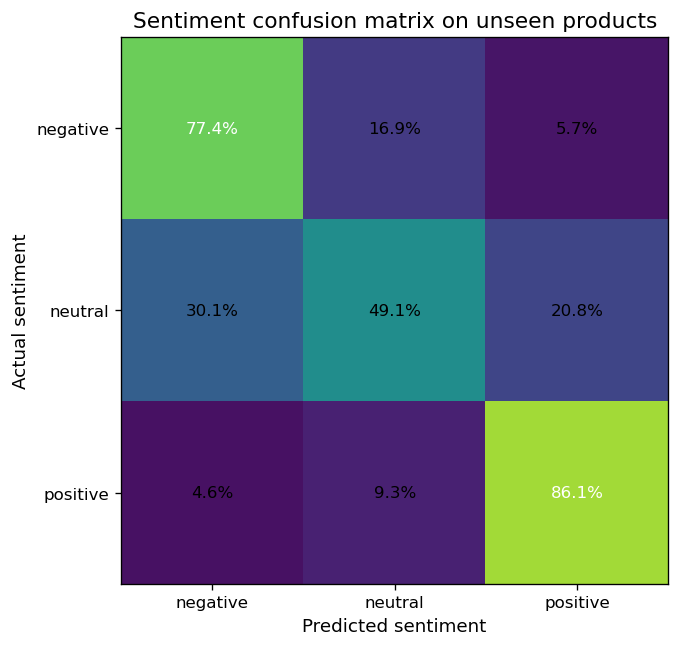

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

evaluation_summary = pd.DataFrame(
    [
        {
            "model": "most-frequent baseline",
            "macro_f1": f1_score(y_test, baseline_predictions, average="macro"),
            "weighted_f1": f1_score(y_test, baseline_predictions, average="weighted"),
            "accuracy": accuracy_score(y_test, baseline_predictions),
        },
        {
            "model": "tf-idf logistic regression",
            "macro_f1": f1_score(y_test, sentiment_predictions, average="macro"),
            "weighted_f1": f1_score(y_test, sentiment_predictions, average="weighted"),
            "accuracy": accuracy_score(y_test, sentiment_predictions),
        },
    ]
)

class_metrics = (
    pd.DataFrame(
        classification_report(
            y_test, sentiment_predictions, labels=sentiment_order,
            output_dict=True, zero_division=0,
        )
    )
    .T.loc[sentiment_order]
    .reset_index(names="sentiment")
    .rename(columns={"f1-score": "f1", "support": "reviews"})
)
class_metrics["reviews"] = class_metrics["reviews"].astype("int64")

confusion_counts = pd.DataFrame(
    confusion_matrix(y_test, sentiment_predictions, labels=sentiment_order),
    index=sentiment_order, columns=sentiment_order,
)
confusion_rates = confusion_counts.div(confusion_counts.sum(axis=1), axis=0)

save_table(evaluation_summary, "sentiment-evaluation-summary")
save_table(class_metrics, "sentiment-class-metrics")
save_diagnostic(confusion_rates.reset_index(names="actual_sentiment"), "sentiment-confusion-rates")

display(evaluation_summary)
display(class_metrics)

figure, axis = plt.subplots(figsize=(7.5, 5.5))
image = axis.imshow(confusion_rates, vmin=0, vmax=1)
for row in range(len(sentiment_order)):
    for column in range(len(sentiment_order)):
        value = confusion_rates.iloc[row, column]
        text_colour = "white" if value >= 0.55 else "black"
        axis.text(column, row, f"{value:.1%}", ha="center", va="center", color=text_colour)
axis.set_xticks(range(len(sentiment_order)), labels=sentiment_order)
axis.set_yticks(range(len(sentiment_order)), labels=sentiment_order)
axis.set(
    title="Sentiment confusion matrix on unseen products",
    xlabel="Predicted sentiment",
    ylabel="Actual sentiment",
)
figure.tight_layout()
save_figure(figure, "sentiment-confusion-matrix")
plt.show()

## Error Analysis

The error analysis focuses on the three most common confusion pathways and retains two high-score disagreements from each. This is enough to distinguish model limitations from disagreement between star ratings and review language without turning the notebook into a catalogue of individual errors. `maximum_model_score` is the largest score returned by the uncalibrated classifier; it ranks examples but is not interpreted as probability.

In [10]:
prediction_results = (
    test_reviews[[
        "rating", "parent_asin", "analysis_text", "clean_text", "clean_word_count",
    ]]
    .copy()
    .assign(
        actual_sentiment=y_test,
        predicted_sentiment=sentiment_predictions,
        maximum_model_score=sentiment_probabilities.max(axis=1),
    )
)
prediction_results["correct_prediction"] = (
    prediction_results["actual_sentiment"] == prediction_results["predicted_sentiment"]
)
prediction_results.reset_index(names="review_index").to_csv(
    prediction_file, index=False, compression="gzip"
)

error_rows = prediction_results.loc[~prediction_results["correct_prediction"]]
error_summary = (
    error_rows.groupby(["actual_sentiment", "predicted_sentiment"], observed=True)
    .agg(
        errors=("clean_text", "size"),
        mean_maximum_model_score=("maximum_model_score", "mean"),
        median_words=("clean_word_count", "median"),
    )
    .reset_index()
    .sort_values(["errors", "mean_maximum_model_score"], ascending=[False, False])
)
error_summary["error_share"] = error_summary["errors"] / error_summary["errors"].sum()

major_error_paths = (
    error_summary.head(3)[["actual_sentiment", "predicted_sentiment"]]
)

error_examples = (
    error_rows.merge(
        major_error_paths,
        on=["actual_sentiment", "predicted_sentiment"],
        how="inner",
    )
    .sort_values("maximum_model_score", ascending=False)
    .groupby(["actual_sentiment", "predicted_sentiment"], observed=True, group_keys=False)
    .head(2)
    [[
        "rating", "actual_sentiment", "predicted_sentiment",
        "maximum_model_score", "clean_word_count", "analysis_text",
    ]]
    .reset_index(drop=True)
)

# Presentation text is decoded independently of the modelling text.
error_examples["analysis_text"] = (
    error_examples["analysis_text"]
    .astype(str)
    .map(html.unescape)
    .str.replace(r"<[^>]+>", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

save_table(error_summary, "sentiment-error-summary")
save_table(error_examples, "sentiment-error-examples")
display(error_summary)
display(error_examples)

,actual_sentiment,predicted_sentiment,errors,mean_maximum_model_score,median_words,error_share
5,positive,neutral,549,0.586,28.000,0.353
0,negative,neutral,293,0.580,26.000,0.188
4,positive,negative,272,0.517,27.000,0.175
2,neutral,negative,204,0.612,25.000,0.131
3,neutral,positive,141,0.603,29.000,0.091
1,negative,positive,98,0.540,26.500,0.063


,rating,actual_sentiment,predicted_sentiment,maximum_model_score,clean_word_count,analysis_text
0,4,positive,neutral,0.971,7,It’s ok very cute but not sturdy
1,2,negative,neutral,0.955,38,Was not as comfortable as I thought it would be. Probably needs to be in some type of pocket in the mask but I don’t...
2,2,negative,neutral,0.946,20,Very tiny and petite steamer. It works okay but is a little wobbly. Constantly have to re tighten the screws.
3,4,positive,neutral,0.941,12,"Not as long lasting as I would have liked, but it’s okay."
4,5,positive,negative,0.882,6,"I found these, was not disappointed."
5,5,positive,negative,0.844,13,My 1st product I've bought that only lasted 2 weeks . Motor burned out


## Topic Modelling

The topic corpus contains English-language negative and neutral reviews only. Common negation contractions have already been expanded, preventing fragments such as `didn` from appearing as topic terms.

Candidate topic counts are assessed on a fixed 8,000-review selection subset using repeated random-initialised NMF fits. Topics are aligned between fits with the Hungarian algorithm before cosine similarity is calculated, while NPMI coherence is estimated from document-level co-occurrence among leading terms.

Five topics are retained because the candidate terms provide a clearer separation of operationally distinct language patterns than the four-topic alternative: value for money, hair-product concerns, direct product failure, durability or staying power, and a broader residual component. The numerical diagnostics remain comparable across the leading candidates, so semantic usefulness—not a marginal metric difference—is the deciding criterion.

The retained topic count is then fitted repeatedly on the **full topic corpus using the same random-initialisation strategy**. The lowest-error full-corpus fit becomes the interpreted model, and stability is reported across those full-corpus fits. This links model-selection diagnostics to the exact model used for interpretation.

The diagnostics assess numerical repeatability on the current sample, not general topic validity under corpus resampling. Topic labels remain analyst interpretations and are audited against competing anchor profiles and representative reviews.

A custom stop-word list preserves **not**, **no** and **nor**, because these terms materially distinguish complaint expressions such as *did not work* from positive statements.

The selection vectoriser is fitted only on the fixed diagnostic subset. After choosing the retained topic count, the vectoriser and NMF model are refitted on the full eligible corpus.

In [11]:
from sklearn.feature_extraction import text
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


def topic_term_diversity(model: NMF, top_terms: int) -> float:
    """
    Calculate topic-term diversity using the highest-weighted terms
    from each topic.

    Inputs:
    -------
    model : sklearn.decomposition.NMF
        Fitted NMF topic model.

    top_terms : int
        Number of highest-weighted terms considered for each topic.

    Outputs:
    --------
    float
        Proportion of unique terms across all selected topic descriptors.
    """
    top_indices = [
        component.argsort()[::-1][:top_terms]
        for component in model.components_
    ]

    flattened = np.concatenate(top_indices)

    return len(np.unique(flattened)) / len(flattened)


def matched_topic_similarity(first: NMF, second: NMF) -> float:
    """
    Measure the similarity between two topic models after aligning
    their topics using the Hungarian algorithm.

    Inputs:
    -------
    first : sklearn.decomposition.NMF
        First fitted NMF model.

    second : sklearn.decomposition.NMF
        Second fitted NMF model.

    Outputs:
    --------
    float
        Mean cosine similarity between the optimally matched topics.
    """
    similarities = cosine_similarity(
        first.components_,
        second.components_,
    )

    rows, columns = linear_sum_assignment(-similarities)

    return float(similarities[rows, columns].mean())


def topic_npmi(model: NMF, matrix, top_terms: int) -> float:
    """
    Calculate the average Normalised Pointwise Mutual Information
    (NPMI) coherence across all topics.

    Inputs:
    -------
    model : sklearn.decomposition.NMF
        Fitted NMF topic model.

    matrix : scipy.sparse matrix
        Document-term matrix used to fit the model.

    top_terms : int
        Number of highest-weighted terms considered for each topic.

    Outputs:
    --------
    float
        Mean NPMI topic coherence.
    """
    document_count = matrix.shape[0]
    topic_scores = []

    for component in model.components_:
        indices = component.argsort()[::-1][:top_terms]

        binary = (
            matrix[:, indices] > 0
        ).astype(np.int64)

        frequencies = np.asarray(
            binary.sum(axis=0)
        ).ravel()

        co_occurrence = (
            binary.T @ binary
        ).toarray()

        pair_scores = []

        for left, right in combinations(
            range(len(indices)),
            2,
        ):
            co_count = int(
                co_occurrence[left, right]
            )

            left_count = int(
                frequencies[left]
            )

            right_count = int(
                frequencies[right]
            )

            if (
                co_count <= 0
                or left_count <= 0
                or right_count <= 0
            ):
                continue

            joint = co_count / document_count
            p_left = left_count / document_count
            p_right = right_count / document_count

            if (
                joint <= 0
                or joint >= 1
                or p_left <= 0
                or p_right <= 0
            ):
                continue

            pmi = np.log(
                joint / (p_left * p_right)
            )

            normalising_term = -np.log(joint)

            if normalising_term <= 0:
                continue

            npmi = pmi / normalising_term

            if np.isfinite(npmi):
                pair_scores.append(float(npmi))

        if pair_scores:
            topic_scores.append(
                float(np.mean(pair_scores))
            )

    return (
        float(np.mean(topic_scores))
        if topic_scores
        else np.nan
    )


topic_reviews = (
    modelling_reviews.loc[
        modelling_reviews["sentiment_label"].isin(
            ["negative", "neutral"]
        )
    ]
    .reset_index(drop=True)
    .copy()
)


# Preserve negation because it materially changes complaint meaning.
custom_stop_words = sorted(
    text.ENGLISH_STOP_WORDS.difference({"not", "no", "nor"})
)

selection_size = min(
    topic_settings["selection_sample_size"],
    len(topic_reviews),
)

selection_indices = np.random.default_rng(random_seed).choice(
    len(topic_reviews),
    size=selection_size,
    replace=False,
)

selection_reviews = topic_reviews.iloc[selection_indices].copy()

selection_vectorizer = TfidfVectorizer(
    max_features=topic_settings["max_features"],
    min_df=topic_settings["min_df"],
    max_df=topic_settings["max_df"],
    stop_words=custom_stop_words,
    ngram_range=(1, 2),
)

selection_matrix = selection_vectorizer.fit_transform(
    selection_reviews["clean_text"]
)

selection_records = []
candidate_models = {}

for n_topics in topic_settings["candidate_topics"]:

    fitted_models = [
        NMF(
            n_components=n_topics,
            init="random",
            random_state=random_seed + run,
            max_iter=500,
        ).fit(selection_matrix)
        for run in range(topic_settings["selection_runs"])
    ]

    pairwise_stability = [
        matched_topic_similarity(first, second)
        for first, second in combinations(fitted_models, 2)
    ]

    representative_model = min(
        fitted_models,
        key=lambda model: model.reconstruction_err_,
    )
    candidate_models[n_topics] = representative_model

    selection_records.append(
        {
            "n_topics": n_topics,
            "mean_reconstruction_error": np.mean(
                [
                    model.reconstruction_err_
                    for model in fitted_models
                ]
            ),
            "stability": np.mean(pairwise_stability),
            "term_diversity": topic_term_diversity(
                representative_model,
                topic_settings["n_top_terms"],
            ),
            "npmi_coherence": topic_npmi(
                representative_model,
                selection_matrix,
                topic_settings["n_top_terms"],
            ),
        }
    )

topic_selection = pd.DataFrame(selection_records)

topic_selection["retained_for_interpretation"] = (
    topic_selection["n_topics"].eq(
        topic_settings["selected_topics"]
    )
)

save_table(
    topic_selection,
    "topic-model-selection",
)

display(topic_selection)


comparison_topic_counts = sorted(
    set([topic_settings["selected_topics"], 5]).intersection(candidate_models)
)
selection_vocabulary = np.asarray(selection_vectorizer.get_feature_names_out())
candidate_term_records = []

for n_topics in comparison_topic_counts:
    for topic_id, component in enumerate(candidate_models[n_topics].components_):
        leading_indices = component.argsort()[::-1][:8]
        candidate_term_records.append(
            {
                "n_topics": n_topics,
                "topic": topic_id,
                "leading_terms": ", ".join(selection_vocabulary[leading_indices]),
            }
        )

candidate_topic_terms = pd.DataFrame(candidate_term_records)
save_diagnostic(candidate_topic_terms, "topic-candidate-terms")
display(candidate_topic_terms)

selected_row = topic_selection.loc[
    topic_selection["retained_for_interpretation"]
].iloc[0]

if selected_row["stability"] < 0.70:
    raise RuntimeError(
        "The selected topic solution is insufficiently stable "
        "for publication. Review the candidate diagnostics "
        "before continuing."
    )

topic_vectorizer = TfidfVectorizer(
    max_features=topic_settings["max_features"],
    min_df=topic_settings["min_df"],
    max_df=topic_settings["max_df"],
    stop_words=custom_stop_words,
    ngram_range=(1, 2),
)

topic_matrix = topic_vectorizer.fit_transform(
    topic_reviews["clean_text"]
)

full_corpus_models = [
    NMF(
        n_components=topic_settings["selected_topics"],
        init="random",
        random_state=random_seed + run,
        max_iter=500,
    ).fit(topic_matrix)
    for run in range(topic_settings["selection_runs"])
]

full_corpus_pairwise_stability = [
    matched_topic_similarity(first, second)
    for first, second in combinations(full_corpus_models, 2)
]

topic_model = min(
    full_corpus_models,
    key=lambda model: model.reconstruction_err_,
)
topic_document_weights = topic_model.transform(topic_matrix)

full_corpus_topic_diagnostic = pd.DataFrame(
    {
        "n_topics": [topic_settings["selected_topics"]],
        "full_corpus_runs": [len(full_corpus_models)],
        "mean_pairwise_stability": [np.mean(full_corpus_pairwise_stability)],
        "minimum_pairwise_stability": [np.min(full_corpus_pairwise_stability)],
        "selected_reconstruction_error": [topic_model.reconstruction_err_],
    }
)

save_diagnostic(full_corpus_topic_diagnostic, "topic-full-corpus-stability")
display(full_corpus_topic_diagnostic)

if full_corpus_topic_diagnostic.loc[0, "mean_pairwise_stability"] < 0.70:
    raise RuntimeError(
        "The full-corpus topic solution is insufficiently stable "
        "for publication. Review the retained topic count."
    )

topic_reviews["topic"] = (
    topic_document_weights.argmax(axis=1)
)

topic_reviews["dominant_topic_weight"] = (
    topic_document_weights.max(axis=1)
)

topic_weight_totals = topic_document_weights.sum(axis=1)

topic_reviews["dominant_topic_share"] = np.divide(
    topic_reviews["dominant_topic_weight"],
    topic_weight_totals,
    out=np.zeros_like(
        topic_reviews["dominant_topic_weight"],
        dtype=float,
    ),
    where=topic_weight_totals > 0,
)

,n_topics,mean_reconstruction_error,stability,term_diversity,npmi_coherence,retained_for_interpretation
0,4,87.632,0.897,0.875,0.155,False
1,5,87.393,0.892,0.850,0.174,True
2,6,87.200,0.877,0.847,0.174,False
3,7,87.015,0.907,0.869,0.172,False
4,8,86.846,0.878,0.833,0.161,False


,n_topics,topic,leading_terms
0,5,0,"does, does not, not, work, not work, stay, not stay, product does"
1,5,1,"hair, hair not, human, brush, human hair, soft, not, hard"
2,5,2,"money, waste, waste money, not waste, not, worth, time, not worth"
3,5,3,"did, did not, not, work, not work, not like, product did, not come"
4,5,4,"not, product, like, use, good, just, really, used"


,n_topics,full_corpus_runs,mean_pairwise_stability,minimum_pairwise_stability,selected_reconstruction_error
0,5,4,1.000,1.000,111.590


## Topic Interpretation

Final topic names are analyst interpretations, not raw model output. Specific anchor profiles are used to keep labels attached to comparable components when topic IDs change between fits. The audit reports both the assigned anchor weight and its margin over competing topics; representative reviews and leading terms remain the final semantic check.

The procedure deliberately leaves one unmatched component as a residual rather than forcing every factor into a narrowly defined business category.

In [12]:
def extract_topic_terms(
    model: NMF,
    vectorizer: TfidfVectorizer,
    top_terms: int,
) -> pd.DataFrame:
    """Return the highest-weighted terms for each fitted topic."""
    vocabulary = np.asarray(vectorizer.get_feature_names_out())
    rows = []

    for topic_id, component in enumerate(model.components_):
        indices = component.argsort()[::-1][:top_terms]
        rows.extend(
            {
                "topic": topic_id,
                "rank": rank,
                "term": vocabulary[index],
                "weight": component[index],
            }
            for rank, index in enumerate(indices, start=1)
        )

    return pd.DataFrame(rows)


topic_terms = extract_topic_terms(
    topic_model,
    topic_vectorizer,
    topic_settings["n_top_terms"],
)

# Profiles distinguish two operationally different forms of product failure:
# immediate ineffectiveness and failure to last, stay or hold.
topic_profiles = {
    "Product did not work as expected": {
        "did not",
        "did not work",
        "not work",
        "product did",
    },
    "Limited durability or staying power": {
        "does not",
        "does not last",
        "not stay",
        "not hold",
        "stay",
        "last",
    },
    "Poor value for money": {
        "money",
        "waste",
        "waste money",
        "not worth",
        "worth money",
    },
    "Hair-product quality concerns": {
        "hair",
        "human hair",
        "wig",
        "brush",
        "tangled",
    },
}
residual_label = "General dissatisfaction (residual)"

topic_actionability = {
    "Product did not work as expected": "high",
    "Limited durability or staying power": "high",
    "Poor value for money": "high",
    "Hair-product quality concerns": "medium",
    residual_label: "low",
}

vocabulary = np.asarray(topic_vectorizer.get_feature_names_out())
term_to_index = {term: index for index, term in enumerate(vocabulary)}
profile_names = list(topic_profiles)

profile_scores = np.zeros((topic_model.n_components, len(profile_names)))
for topic_id, component in enumerate(topic_model.components_):
    for profile_id, profile_name in enumerate(profile_names):
        profile_scores[topic_id, profile_id] = sum(
            component[term_to_index[term]]
            for term in topic_profiles[profile_name]
            if term in term_to_index
        )

# One-to-one matching prevents two labels from being attached to the same
# component. The fifth, unmatched component remains explicitly residual.
matched_topics, matched_profiles = linear_sum_assignment(-profile_scores)
topic_labels = {
    int(topic_id): profile_names[int(profile_id)]
    for topic_id, profile_id in zip(matched_topics, matched_profiles)
}

remaining_topics = set(range(topic_model.n_components)) - set(topic_labels)
if len(remaining_topics) != 1:
    raise RuntimeError("Expected exactly one unmatched residual topic.")
topic_labels[remaining_topics.pop()] = residual_label

topic_terms["topic_label"] = topic_terms["topic"].map(topic_labels)
topic_reviews["topic_label"] = topic_reviews["topic"].map(topic_labels)
topic_reviews["actionability"] = topic_reviews["topic_label"].map(topic_actionability)

anchor_rows = []
for topic_id, label in sorted(topic_labels.items()):
    leading_terms = ", ".join(
        topic_terms.loc[
            topic_terms["topic"].eq(topic_id)
            & topic_terms["rank"].le(8),
            "term",
        ]
    )

    if label == residual_label:
        anchor_rows.append(
            {
                "topic": topic_id,
                "topic_label": label,
                "assigned_anchor_weight": np.nan,
                "next_best_topic_weight": np.nan,
                "assignment_margin": np.nan,
                "topic_anchor_share": np.nan,
                "leading_terms": leading_terms,
            }
        )
        continue

    profile_id = profile_names.index(label)
    assigned_weight = profile_scores[topic_id, profile_id]
    competing_topic_weights = np.delete(profile_scores[:, profile_id], topic_id)
    next_best_topic_weight = competing_topic_weights.max(initial=0.0)
    topic_profile_total = profile_scores[topic_id].sum()

    anchor_rows.append(
        {
            "topic": topic_id,
            "topic_label": label,
            "assigned_anchor_weight": assigned_weight,
            "next_best_topic_weight": next_best_topic_weight,
            "assignment_margin": assigned_weight - next_best_topic_weight,
            "topic_anchor_share": (
                assigned_weight / topic_profile_total
                if topic_profile_total > 0
                else np.nan
            ),
            "leading_terms": leading_terms,
        }
    )

anchor_audit = pd.DataFrame(anchor_rows)

specific_audit = anchor_audit.loc[
    anchor_audit["topic_label"].ne(residual_label)
]
if (specific_audit["assigned_anchor_weight"] <= 0).any():
    raise RuntimeError(
        "At least one specific topic label lacks support from its anchor profile."
    )
if (specific_audit["assignment_margin"] <= 0).any():
    raise RuntimeError(
        "At least one topic label is not the strongest component for its anchor profile."
    )

topic_summary = (
    topic_reviews
    .groupby(["topic", "topic_label", "actionability"], observed=True)
    .agg(
        reviews=("clean_text", "size"),
        products=("parent_asin", "nunique"),
        negative_share=(
            "sentiment_label",
            lambda values: (values == "negative").mean(),
        ),
        median_dominant_topic_share=("dominant_topic_share", "median"),
    )
    .reset_index()
)

topic_summary["dominant_assignment_share"] = (
    topic_summary["reviews"] / topic_summary["reviews"].sum()
)
corpus_negative_share = topic_reviews["sentiment_label"].eq("negative").mean()
topic_summary["negative_share_difference_pp"] = (
    (topic_summary["negative_share"] - corpus_negative_share) * 100
)

actionability_order = {"high": 0, "medium": 1, "low": 2}
topic_summary["actionability_order"] = topic_summary["actionability"].map(
    actionability_order
)
topic_summary = (
    topic_summary
    .sort_values(
        ["actionability_order", "reviews"],
        ascending=[True, False],
    )
    .drop(columns="actionability_order")
    .reset_index(drop=True)
)

representative_candidates = (
    topic_reviews.loc[
        topic_reviews["clean_word_count"].between(12, 120)
    ]
    .copy()
)
representative_candidates["display_text"] = (
    representative_candidates["analysis_text"]
    .astype(str)
    .map(html.unescape)
    .str.replace(r"\[\[(?:VIDEOID|IMAGEID):[^\]]+\]\]", " ", regex=True)
    .str.replace(r"<[^>]+>", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
representative_candidates = representative_candidates.loc[
    representative_candidates["display_text"].str.split().str.len().between(12, 120)
].copy()

representative_candidates["deduplication_key"] = (
    representative_candidates["display_text"].str.lower()
)
representative_candidates = representative_candidates.drop_duplicates(
    ["topic", "deduplication_key"]
)

representative_reviews = (
    representative_candidates
    .sort_values(
        ["topic", "dominant_topic_weight", "clean_word_count"],
        ascending=[True, False, False],
    )
    .groupby("topic", observed=True, group_keys=False)
    .head(2)
    [[
        "topic_label",
        "rating",
        "display_text",
    ]]
    .rename(columns={"display_text": "analysis_text"})
    .reset_index(drop=True)
)

save_table(topic_summary, "topic-summary")
save_table(representative_reviews, "representative-topic-reviews")
save_diagnostic(topic_terms, "topic-terms")
save_diagnostic(anchor_audit, "topic-label-anchor-audit")

topic_summary_display = topic_summary.drop(columns="topic").style.format(
    {
        "reviews": "{:,.0f}",
        "products": "{:,.0f}",
        "negative_share": "{:.1%}",
        "median_dominant_topic_share": "{:.2f}",
        "dominant_assignment_share": "{:.1%}",
        "negative_share_difference_pp": "{:+.1f}",
    }
)

display(topic_summary_display)
display(topic_terms.loc[topic_terms["rank"].le(8)])
display(anchor_audit)
display(representative_reviews)

,topic_label,actionability,reviews,products,negative_share,median_dominant_topic_share,dominant_assignment_share,negative_share_difference_pp
0,Product did not work as expected,high,"1,243","1,117",75.7%,0.67,9.6%,+4.3
1,Limited durability or staying power,high,"1,122","1,010",73.1%,0.67,8.6%,+1.6
2,Poor value for money,high,705,661,94.8%,0.68,5.4%,+23.3
3,Hair-product quality concerns,medium,"1,739","1,471",70.8%,0.69,13.4%,-0.7
4,General dissatisfaction (residual),low,"8,176","6,259",68.7%,0.86,63.0%,-2.7


,topic,rank,term,weight,topic_label
0,0,1,did,2.300,Product did not work as expected
1,0,2,did not,2.182,Product did not work as expected
2,0,3,not,1.039,Product did not work as expected
3,0,4,work,0.905,Product did not work as expected
4,0,5,not work,0.877,Product did not work as expected
5,0,6,not like,0.350,Product did not work as expected
6,0,7,product did,0.250,Product did not work as expected
7,0,8,like,0.166,Product did not work as expected
12,1,1,not,1.498,General dissatisfaction (residual)
13,1,2,product,0.959,General dissatisfaction (residual)


,topic,topic_label,assigned_anchor_weight,next_best_topic_weight,assignment_margin,topic_anchor_share,leading_terms
0,0,Product did not work as expected,3.309,0.742,2.567,0.944,"did, did not, not, work, not work, not like, product did, like"
1,1,General dissatisfaction (residual),NaN,NaN,NaN,NaN,"not, product, like, use, good, just, no, buy"
2,2,Poor value for money,4.956,0.221,4.735,0.990,"money, waste, waste money, not waste, not, worth, not worth, time"
3,3,Limited durability or staying power,2.924,0.193,2.731,0.784,"does, does not, not, work, not work, not stay, stay, product does"
4,4,Hair-product quality concerns,3.340,0.368,2.972,0.958,"hair, hair not, human, human hair, not, soft, brush, wig"


,topic_label,rating,analysis_text
0,Product did not work as expected,1,This didn't work at all did not get one blackhead off so I thought if I used it multiple times it would but still di...
1,Product did not work as expected,2,"This didn't work out for me. Seems well made, but I didn't like the texture or color."
2,General dissatisfaction (residual),1,These sting my face really bad. They are not soothing at all! Disappointed. I used one of these wipes and can’t use ...
3,General dissatisfaction (residual),1,These are terrible. I have to use two to three wipes to get all my makeup off and they are really rough on your face...
4,Poor value for money,1,Waste of money. There are wayyyy better face masks than this and those and probably better for your skin. Just don't...
5,Poor value for money,1,When you use the tattoos they don't stay on your head they ball up it's a waste of money don't waste your time or money
6,Limited durability or staying power,2,It does not work......the heads does not do anything to the nails it is too cheap.
7,Limited durability or staying power,1,Doesn’t work at all. The pieces don’t even line up. It doesn’t cut or grab. Literally does nothing
8,Hair-product quality concerns,1,at first the hair was soft with no weird smell. After installing the hair even after using a heat protector it would...
9,Hair-product quality concerns,1,This is the second time I’ve ordered this hair. This time was terrible. The locs are extremely curly so it doesn’t l...


## Business Interpretation

The sentiment classifier provides a scalable ranking layer for human review, but its scores are not calibrated probabilities and should not be used as automatic escalation thresholds without a separate operating-cost and calibration study.

The topic model identifies recurring language patterns among English negative and neutral reviews. It does not produce a complete complaint taxonomy. Four components are interpreted as specific exploratory lenses—direct product failure, limited durability or staying power, poor value for money, and hair-product quality concerns—while one broader component remains explicitly residual.

Raw review counts describe the composition of this corpus rather than the incidence or severity of customer problems. Product-family sales volume is not available as a denominator, so the largest component should not automatically receive the highest business priority. Prioritisation should combine review volume, spread across products, relative negative concentration and analyst-assessed actionability.

**Poor value for money** is expected to be especially useful when its negative share is elevated relative to the topic corpus. **Product did not work as expected** and **limited durability or staying power** provide separate operational starting points: the first concerns immediate failure to deliver the promised result, while the second concerns products that do not last, stay or hold. **Hair-product quality concerns** is category-specific and should be interpreted in light of the product mix within All Beauty. The residual component remains a low-actionability collection of more general dissatisfaction rather than a discrete customer issue.

The **actionability** assessment is analyst-defined rather than model-derived. It structures operational discussion and prioritisation; it does not estimate objective business impact.

In [13]:
model_result = evaluation_summary.loc[
    evaluation_summary["model"].eq("tf-idf logistic regression")
].iloc[0]
baseline_result = evaluation_summary.loc[
    evaluation_summary["model"].eq("most-frequent baseline")
].iloc[0]

largest_topic = topic_summary.sort_values(
    "dominant_assignment_share", ascending=False
).iloc[0]

print(
    "Primary unseen-product macro F1: "
    f"{model_result['macro_f1']:.3f} "
    f"(baseline improvement: "
    f"{model_result['macro_f1'] - baseline_result['macro_f1']:.3f})."
)
print(
    "Repeated grouped macro F1: "
    f"{robustness_summary.loc[0, 'mean_macro_f1']:.3f} "
    f"± {robustness_summary.loc[0, 'std_macro_f1']:.3f} "
    f"across {sentiment_robustness_splits} additional splits."
)
print(
    "Negative share in the topic corpus: "
    f"{corpus_negative_share:.1%}."
)
print(
    "Largest dominant topic assignment: "
    f"{largest_topic['topic_label']} "
    f"({largest_topic['dominant_assignment_share']:.1%} of the topic corpus)."
)

Primary unseen-product macro F1: 0.674 (baseline improvement: 0.396).
Repeated grouped macro F1: 0.682 ± 0.002 across 5 additional splits.
Negative share in the topic corpus: 71.5%.
Largest dominant topic assignment: General dissatisfaction (residual) (63.0% of the topic corpus).


## Conclusions

This notebook implements a reproducible and leakage-aware workflow for customer-review analysis. TF–IDF with logistic regression provides an interpretable sentiment baseline and is evaluated on products not observed during training. Comparison with a naive baseline, five additional grouped splits and class-level error analysis shows clear value while also exposing the difficulty of the rating-derived neutral class.

The exploratory topic component is restricted to an English-language negative and neutral corpus. Candidate topic counts are assessed using features fitted only on a fixed selection subset. Five topics are retained because their leading terms provide a clearer separation of operationally distinct complaint language than the more compact alternative. The retained count is then refitted repeatedly on the full corpus. Stability supports numerical reproducibility, but it does not establish a complete or uniquely meaningful complaint taxonomy.

Topic proportions are reported as dominant NMF assignments rather than estimates of complaint incidence. Four specific themes provide exploratory lenses for investigation: poor value for money, products that did not work as expected, limited durability or staying power, and hair-product quality concerns. A fifth component remains explicitly residual. The model is therefore suitable for human-led investigation and triage, not automated complaint routing.

The main limitations are the use of star ratings as sentiment proxies, the disproportionate exclusion of short positive reviews through language and length rules, the absence of calibrated probabilities, and the lack of product-family denominators for estimating complaint rates. Within those limits, the sentiment workflow is a credible analytical baseline and the topic workflow offers a cautious, auditable view of recurring concerns without implying production readiness.

## Export Trained Sentiment Pipeline

The grouped holdout above remains the basis for model evaluation. For local serving, a fresh copy of the same pipeline is fitted on the complete modelling dataset and exported as a single artefact. Keeping TF–IDF and logistic regression inside one scikit-learn `Pipeline` ensures that inference applies the same feature transformation used during training.

The artefacts are written to the project-level `artifacts/` directory so that the sibling `azure/` implementation can load them without depending on notebook internals. The metadata records the model contract and training context; it is descriptive rather than a substitute for formal model versioning.

In [14]:
from datetime import datetime, timezone

import joblib
import sklearn

artifacts_dir = project_root / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

production_sentiment_pipeline = clone(sentiment_pipeline)
production_sentiment_pipeline.fit(
    modelling_reviews["clean_text"],
    modelling_reviews["sentiment_label"].astype(str),
)

pipeline_path = artifacts_dir / "sentiment_pipeline.joblib"
metadata_path = artifacts_dir / "sentiment_pipeline_metadata.json"

joblib.dump(production_sentiment_pipeline, pipeline_path)

classifier = production_sentiment_pipeline.named_steps["classifier"]
metadata = {
    "artifact_name": pipeline_path.name,
    "artifact_type": "scikit-learn Pipeline",
    "project": "Understanding Customer Feedback through NLP",
    "dataset": "Amazon Reviews 2023",
    "review_category": review_category,
    "exported_at_utc": datetime.now(timezone.utc).isoformat(),
    "scikit_learn_version": sklearn.__version__,
    "random_seed": random_seed,
    "training_reviews": int(len(modelling_reviews)),
    "training_products": int(modelling_reviews["parent_asin"].nunique()),
    "input_schema": {
        "text": "Raw customer-review text supplied as a non-empty string."
    },
    "preprocessing": {
        "function": "normalise_review_text",
        "minimum_words_used_during_training": minimum_nlp_words,
        "training_language": "English",
    },
    "target_definition": {
        "negative": "ratings 1-2",
        "neutral": "rating 3",
        "positive": "ratings 4-5",
    },
    "classes": classifier.classes_.tolist(),
    "model": classifier.__class__.__name__,
    "vectorizer": production_sentiment_pipeline.named_steps["tfidf"].__class__.__name__,
    "primary_evaluation": {
        "design": "product-grouped holdout",
        "metric": "macro_f1",
        "value": float(model_result["macro_f1"]),
    },
}

metadata_path.write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

# Confirm that the serialised pipeline can be loaded and used independently.
loaded_pipeline = joblib.load(pipeline_path)
smoke_test_text = normalise_review_text(
    "The product arrived quickly and worked exactly as expected."
)
smoke_test_prediction = loaded_pipeline.predict([smoke_test_text])[0]
smoke_test_scores = dict(
    zip(
        loaded_pipeline.named_steps["classifier"].classes_,
        loaded_pipeline.predict_proba([smoke_test_text])[0],
    )
)

print(f"Pipeline exported to: {pipeline_path}")
print(f"Metadata exported to: {metadata_path}")
print(f"Smoke-test prediction: {smoke_test_prediction}")
print(
    "Smoke-test scores: "
    + ", ".join(
        f"{label}={score:.3f}"
        for label, score in smoke_test_scores.items()
    )
)

Pipeline exported to: C:\Users\Rodrigo\Desktop\profile\portfolio\notebooks-and-scripts\2-retail-analytics\3-customer-feedback-nlp\artifacts\sentiment_pipeline.joblib
Metadata exported to: C:\Users\Rodrigo\Desktop\profile\portfolio\notebooks-and-scripts\2-retail-analytics\3-customer-feedback-nlp\artifacts\sentiment_pipeline_metadata.json
Smoke-test prediction: positive
Smoke-test scores: negative=0.022, neutral=0.087, positive=0.891
